In [30]:
import os
import copy
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1)
drive.mount('/content/drive')
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


In [ ]:
#data = torch.load("/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_raw_dataset.pt")
data = torch.load("/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_av_raw_dataset.pt")

X_train_full = data["X_train"].float()
y_train_full = data["y_train"].float().view(-1, 1)
X_test = data["X_test"].float()
y_test = data["y_test"].float().view(-1, 1)

feature_names = data.get("feature_names", ["S0", "Y0", "kappa", "mu", "sigma", "r", "rho", "K", "T"])
print("Train full:", X_train_full.shape, y_train_full.shape)
print("Test      :", X_test.shape, y_test.shape)


Train full: torch.Size([100000, 9]) torch.Size([100000, 1])
Test      : torch.Size([20000, 9]) torch.Size([20000, 1])


In [ ]:
val_ratio = 0.10
n_total = len(X_train_full)
n_val = int(val_ratio * n_total)
n_train = n_total - n_val

dataset_full = TensorDataset(X_train_full, y_train_full)
generator = torch.Generator().manual_seed(42)
train_dataset_raw, val_dataset_raw = random_split(dataset_full, [n_train, n_val], generator=generator)

X_train_raw = train_dataset_raw.dataset.tensors[0][train_dataset_raw.indices]
y_train_raw = train_dataset_raw.dataset.tensors[1][train_dataset_raw.indices]

X_val_raw = val_dataset_raw.dataset.tensors[0][val_dataset_raw.indices]
y_val_raw = val_dataset_raw.dataset.tensors[1][val_dataset_raw.indices]

print("Train split:", X_train_raw.shape, y_train_raw.shape)
print("Val split  :", X_val_raw.shape, y_val_raw.shape)

Train split: torch.Size([90000, 9]) torch.Size([90000, 1])
Val split  : torch.Size([10000, 9]) torch.Size([10000, 1])


In [ ]:
# Standardize X using TRAIN statistics
x_mean = X_train_raw.mean(dim=0, keepdim=True)
x_std = X_train_raw.std(dim=0, keepdim=True).clamp_min(1e-8)
X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test_std = (X_test - x_mean) / x_std
y_train = y_train_raw
y_val = y_val_raw
y_test_std_target = y_test

# DataLoaders
batch_size = 1024
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_std, y_test_std_target)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
def full_metrics(y_pred, y_true, min_price=0.5):
    y_pred = y_pred.squeeze()
    y_true = y_true.squeeze()

    mask_atm = y_true > min_price
    mask_otm = ~mask_atm

    abs_err = torch.abs(y_pred - y_true)
    err_np  = (y_pred - y_true).cpu().numpy()
    abs_np  = abs_err.cpu().numpy()

    def rel(pred, true):
        return (torch.abs(pred - true) / (true + 1e-3)).mean().item()

    def rel2(pred, true):
      return (torch.abs(pred - true) / (true)).mean().item()

    return {
        # Global
        "mae":           abs_err.mean().item(),
        "rmse":          torch.sqrt(((y_pred - y_true)**2).mean()).item(),
        "rel_err_total": rel(y_pred, y_true),
        "rel_err":   rel2(y_pred[mask_atm], y_true[mask_atm]) if mask_atm.sum() > 0 else float('nan'),

        # Distribution
        "error_mean":    float(err_np.mean()),
        "error_std":     float(err_np.std()),
        "abs_p50":       float(np.percentile(abs_np, 50)),
        "abs_p90":       float(np.percentile(abs_np, 90)),
        "abs_p95":       float(np.percentile(abs_np, 95)),
        "abs_p99":       float(np.percentile(abs_np, 99)),
    }

In [35]:
'''
class WeightedHuberLoss(nn.Module):
    def __init__(self, delta=0.5, eps=1.0):
        super().__init__()
        self.delta = delta
        self.eps = eps

    def forward(self, pred, target):
        weights = torch.log1p(target / self.eps + 1.0)
        huber = F.huber_loss(pred, target, delta=self.delta, reduction='none')
        return (weights * huber).mean()
'''

class HestonMLP(nn.Module):
    def __init__(self, input_dim=9, dropout=0.05):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.drop4 = nn.Dropout(dropout)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.drop4(x)

        x = self.out(x)
        return x


In [36]:
@torch.no_grad()
def evaluate_model(model, loader, device=device):
    model.eval()
    preds_all, targets_all = [], []
    for xb, yb in loader:
        preds_all.append(model(xb.to(device)))
        targets_all.append(yb.to(device))
    preds_all  = torch.cat(preds_all).cpu()
    targets_all = torch.cat(targets_all).cpu()
    return full_metrics(preds_all, targets_all), preds_all, targets_all


def train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=20,
    lr=1e-3,
    weight_decay=1e-5,
    patience=12,
    grad_clip=None,
    device=device
):
    model = model.to(device)

    criterion = nn.HuberLoss(delta=0.5)
    #criterion = WeightedHuberLoss(delta=0.5, eps=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-5
    )

    history = {
        "train_loss": [],
        "train_mae": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_rel_err": [],
        "lr": [],
    }

    best_model_state = None
    best_val_mae = float("inf")
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        model.train()

        running_loss = 0.0
        running_mae_sum = 0.0
        running_n = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}", leave=False)

        for xb, yb in progress_bar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            batch_n = xb.size(0)
            running_loss += loss.item() * batch_n
            running_mae_sum += torch.sum(torch.abs(pred.detach() - yb)).item()
            running_n += batch_n

            progress_bar.set_postfix({
                "train_loss": f"{running_loss / running_n:.5f}",
                "train_mae": f"{running_mae_sum / running_n:.5f}",
                "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
            })

        train_loss = running_loss / running_n
        train_mae = running_mae_sum / running_n

        val_metrics, _, _ = evaluate_model(model, val_loader, device=device)
        scheduler.step(val_metrics["mae"])

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_metrics["mae"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_rel_err"].append(val_metrics["rel_err_total"])
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.6f} | train_mae={train_mae:.6f} | "
            f"val_mae={val_metrics['mae']:.6f} | val_rmse={val_metrics['rmse']:.6f} | "
            f"val_rel_total={val_metrics['rel_err_total']:.6f} | val_rel_atm={val_metrics['rel_err']:.6f} | "
            f"lr={current_lr:.2e}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after epoch {epoch}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history


In [ ]:
model = HestonMLP(input_dim=9, dropout=0.05).to(device)
print(model)

HestonMLP(
  (fc1): Linear(in_features=9, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.05, inplace=False)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.05, inplace=False)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop4): Dropout(p=0.05, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
)


In [38]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    grad_clip=None,
    device=device
)

Epoch 001 | train_loss=9.445321 | train_mae=19.138797 | val_mae=17.487591 | val_rmse=22.368965 | val_rel_total=1.658157 | val_rel_atm=0.776588 | lr=1.00e-03


Epoch 002 | train_loss=7.602881 | train_mae=15.449611 | val_mae=12.966628 | val_rmse=18.007147 | val_rel_total=1.475493 | val_rel_atm=0.538667 | lr=1.00e-03


Epoch 003 | train_loss=4.584823 | train_mae=9.413718 | val_mae=4.455104 | val_rmse=6.521942 | val_rel_total=1.564644 | val_rel_atm=0.307015 | lr=1.00e-03


Epoch 004 | train_loss=1.177050 | train_mae=2.588366 | val_mae=0.973804 | val_rmse=1.244969 | val_rel_total=1.562415 | val_rel_atm=0.102487 | lr=1.00e-03


Epoch 005 | train_loss=0.477637 | train_mae=1.179182 | val_mae=0.525455 | val_rmse=0.661727 | val_rel_total=1.542454 | val_rel_atm=0.057464 | lr=1.00e-03


...

Epoch 071 | train_loss=0.306201 | train_mae=0.823913 | val_mae=0.175657 | val_rmse=0.233182 | val_rel_total=1.615576 | val_rel_atm=0.016372 | lr=1.56e-05


Epoch 072 | train_loss=0.294715 | train_mae=0.799689 | val_mae=0.339246 | val_rmse=0.430207 | val_rel_total=1.620768 | val_rel_atm=0.022426 | lr=1.56e-05


Epoch 073 | train_loss=0.306573 | train_mae=0.823799 | val_mae=0.168119 | val_rmse=0.218456 | val_rel_total=1.614393 | val_rel_atm=0.015578 | lr=1.56e-05


Epoch 074 | train_loss=0.304323 | train_mae=0.819521 | val_mae=0.292358 | val_rmse=0.368846 | val_rel_total=1.618511 | val_rel_atm=0.020159 | lr=1.56e-05


Epoch 075 | train_loss=0.306321 | train_mae=0.823829 | val_mae=0.252777 | val_rmse=0.338071 | val_rel_total=1.616538 | val_rel_atm=0.017874 | lr=1.00e-05
Early stopping triggered after epoch 75.


In [48]:
train_metrics, train_preds, train_targets = evaluate_model(model, train_loader, device=device)
val_metrics, val_preds, val_targets = evaluate_model(model, val_loader, device=device)
test_metrics, test_preds, test_targets = evaluate_model(model, test_loader, device=device)

print("\nFinal metrics")
print("TRAIN:", train_metrics)
print("VAL  :", val_metrics)
print("TEST :", test_metrics)


Final metrics
TRAIN: {'mae': 0.16435733437538147, 'rmse': 0.2163509875535965, 'rel_err_total': 1.7198368310928345, 'rel_err': 0.013967527076601982, 'error_mean': 0.03818489983677864, 'error_std': 0.2129545956850052, 'abs_p50': 0.1293487548828125, 'abs_p90': 0.3541015684604645, 'abs_p95': 0.4369783401489258, 'abs_p99': 0.6259101629257202}
VAL  : {'mae': 0.16646429896354675, 'rmse': 0.21862012147903442, 'rel_err_total': 1.6136937141418457, 'rel_err': 0.013816658407449722, 'error_mean': 0.035034436732530594, 'error_std': 0.21579468250274658, 'abs_p50': 0.13035261631011963, 'abs_p90': 0.35703450441360474, 'abs_p95': 0.44091424345970154, 'abs_p99': 0.6318182945251465}
TEST : {'mae': 0.15548156201839447, 'rmse': 0.20787200331687927, 'rel_err_total': 1.7240195274353027, 'rel_err': 0.013141650706529617, 'error_mean': 0.03945218399167061, 'error_std': 0.2040938436985016, 'abs_p50': 0.12002038955688477, 'abs_p90': 0.33612287044525146, 'abs_p95': 0.42160630226135254, 'abs_p99': 0.612349569797515

In [40]:
# Save model + preprocessing stats
save_dict = {
    "model_state_dict": model.state_dict(),
    "x_mean": x_mean,
    "x_std": x_std,
    "feature_names": feature_names,
    "history": history,
    "model_config": {
        "input_dim": 9,
        "hidden_dims": (256, 256, 128, 64),
        "dropout": 0.05
    }
}
torch.save(save_dict, "/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_mlp_model.pt")
print("Model saved.")


Model saved.


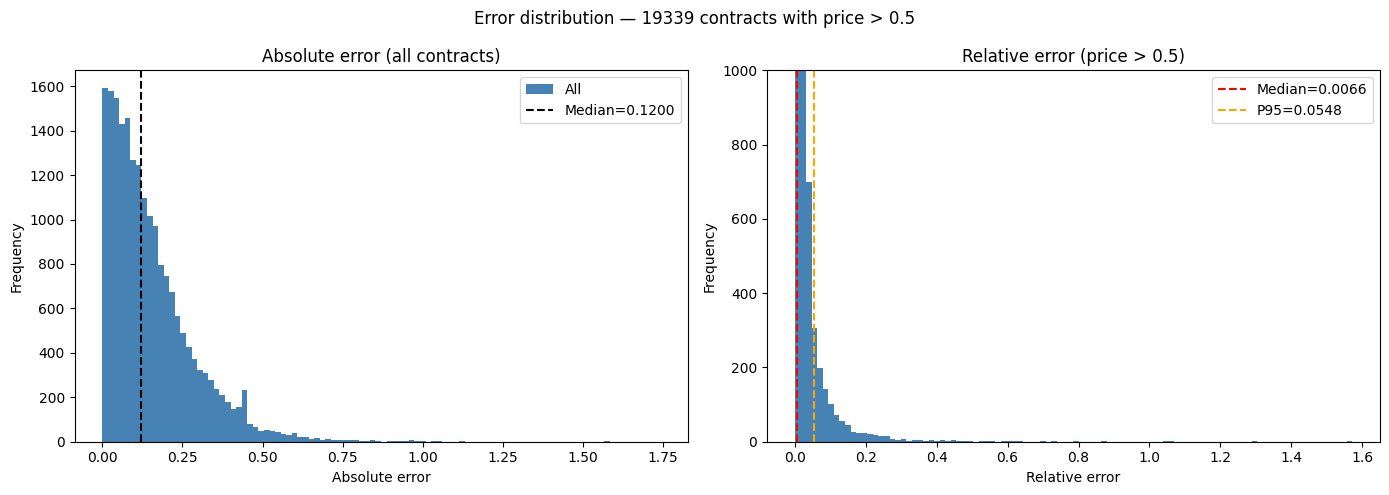

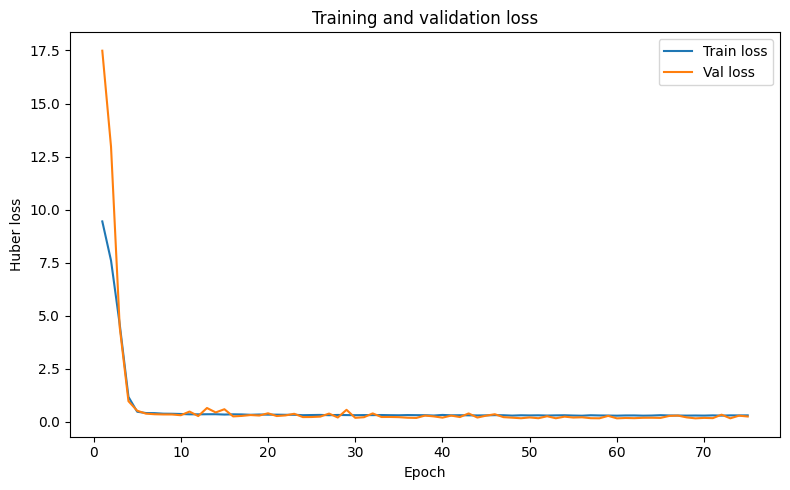

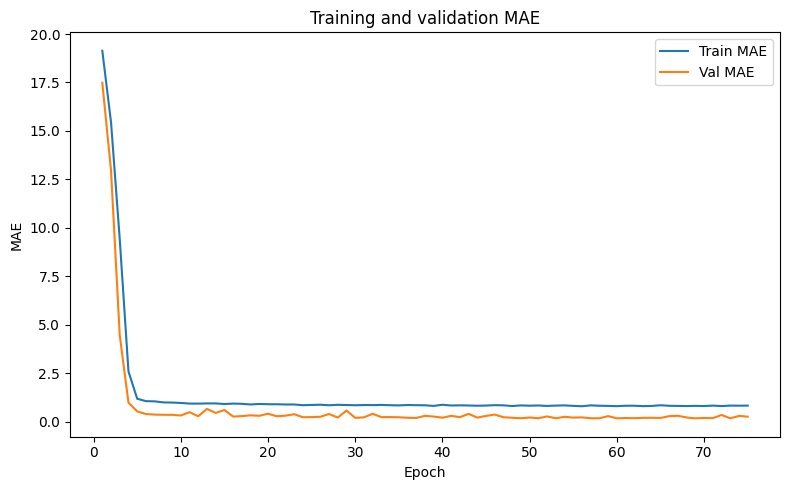

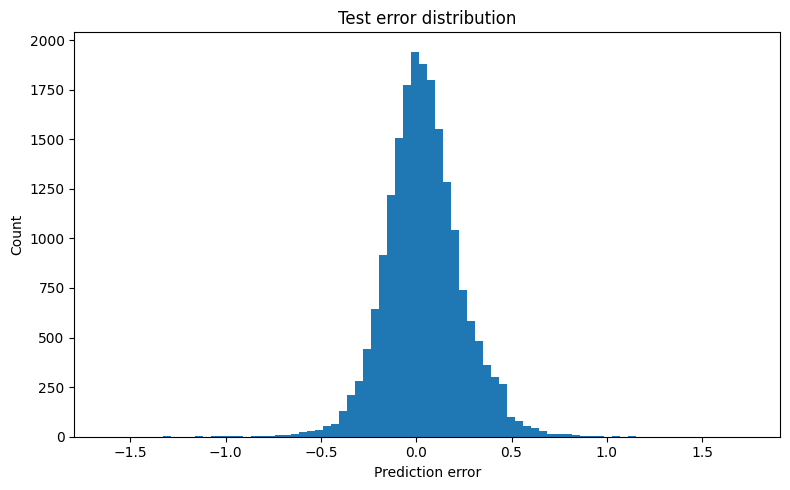

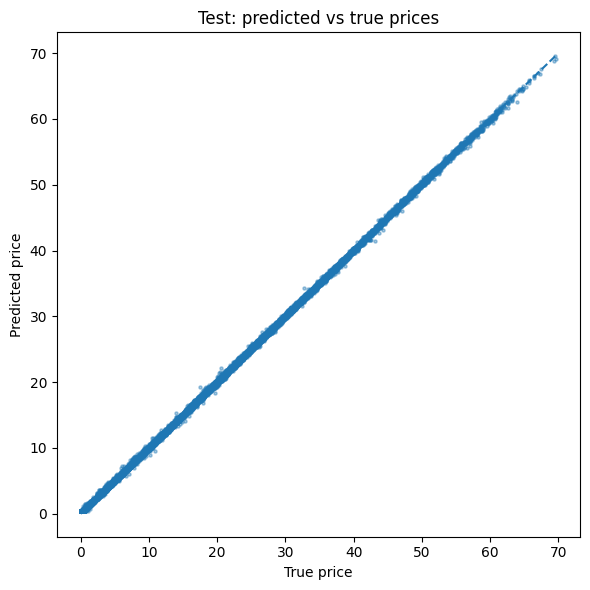

In [ ]:
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Huber loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_mae"], label="Train MAE")
    plt.plot(epochs, history["val_mae"], label="Val MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Training and validation MAE")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_error_distribution(y_pred, y_true, title="Error distribution"):
    err = (y_pred - y_true).detach().cpu().numpy().reshape(-1)

    plt.figure(figsize=(8, 5))
    plt.hist(err, bins=80)
    plt.xlabel("Prediction error")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_pred_vs_true(y_pred, y_true, title="Predicted vs true prices"):
    y_pred_np = y_pred.detach().cpu().numpy().reshape(-1)
    y_true_np = y_true.detach().cpu().numpy().reshape(-1)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_np, y_pred_np, s=5, alpha=0.4)
    mn = min(y_true_np.min(), y_pred_np.min())
    mx = max(y_true_np.max(), y_pred_np.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True price")
    plt.ylabel("Predicted price")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_error_histograms(y_pred, y_true, X_raw, min_price=0.25):
    y_pred  = y_pred.detach().cpu().numpy().reshape(-1)
    y_true  = y_true.detach().cpu().numpy().reshape(-1)

    mask = y_true > min_price
    S0 = X_raw[:, 0].cpu().numpy()
    K  = X_raw[:, 7].cpu().numpy()
    mask_otm = S0 < K

    abs_err = np.abs(y_pred - y_true)
    rel_err = np.abs(y_pred[mask] - y_true[mask]) / y_true[mask]  # pas d'epsilon

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Error distribution — {mask.sum()} contracts with price > {min_price}")
    axes[0].hist(abs_err, bins=100, edgecolor='none', color='steelblue', label='All')
    axes[0].axvline(np.median(abs_err), color='k', linestyle='--', label=f'Median={np.median(abs_err):.4f}')
    axes[0].set_xlabel("Absolute error")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Absolute error (all contracts)")
    axes[0].legend()

    axes[1].hist(rel_err, bins=100, edgecolor='none', color='steelblue')
    axes[1].axvline(np.median(rel_err), color='r', linestyle='--', label=f'Median={np.median(rel_err):.4f}')
    axes[1].axvline(np.percentile(rel_err, 95), color='orange', linestyle='--', label=f'P95={np.percentile(rel_err, 95):.4f}')
    axes[1].set_xlabel("Relative error")
    axes[1].set_ylabel("Frequency")
    axes[1].set_ylim(0, 1000)
    axes[1].set_title(f"Relative error (price > {min_price})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_error_histograms(test_preds, test_targets, X_test, min_price=0.5)
plot_training_history(history)
plot_error_distribution(test_preds, test_targets, title="Test error distribution")
plot_pred_vs_true(test_preds, test_targets, title="Test: predicted vs true prices")

In [ ]:
MIN_PRICE_REL=0.5

@torch.no_grad()
def get_predictions_dataframe(model, X_raw, y_true, x_mean, x_std, feature_names, device, min_price_rel=MIN_PRICE_REL):
    """
    X_raw : raw (non-standardized) inputs, shape (N, 9)
    y_true: true prices, shape (N,) or (N,1)
    """
    model.eval()

    X_std = (X_raw - x_mean) / x_std
    X_std = X_std.to(device)
    y_pred = model(X_std).detach().cpu().reshape(-1)
    y_true = y_true.detach().cpu().reshape(-1)

    X_np = X_raw.detach().cpu().numpy()
    df = pd.DataFrame(X_np, columns=feature_names)

    df["y_true"] = y_true.numpy()
    df["y_pred"] = y_pred.numpy()
    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
    df["signed_error"] = df["y_pred"] - df["y_true"]

    # raw relative error stored but should only be analyzed on filtered subset
    df["rel_error"] = df["abs_error"] / (np.abs(df["y_true"]) + 1e-6)
    df["moneyness"] = df["S0"] / df["K"]
    df["rel_mask"] = df["y_true"] > min_price_rel

    return df


def filter_relative_error_df(df, min_price_rel=MIN_PRICE_REL):
    return df[df["y_true"] > min_price_rel].copy()


# MONEyness BUCKETS
def add_moneyness_bucket(df, atm_band=0.02):
    """
    ATM if 1-atm_band <= S0/K <= 1+atm_band
    """
    m = df["moneyness"]

    conditions = [
        m < 1.0 - atm_band,
        (m >= 1.0 - atm_band) & (m <= 1.0 + atm_band),
        m > 1.0 + atm_band
    ]
    labels = ["OTM", "ATM", "ITM"]

    df = df.copy()
    df["contract_type"] = np.select(conditions, labels, default="ATM")
    return df



# CONTRACT-TYPE PLOTS
def plot_error_by_contract_type(df, error_col="abs_error", atm_band=0.02):
    df_plot = add_moneyness_bucket(df, atm_band=atm_band)

    order = ["OTM", "ATM", "ITM"]
    grouped = df_plot.groupby("contract_type")[error_col]

    means = [grouped.mean().get(k, np.nan) for k in order]
    medians = [grouped.median().get(k, np.nan) for k in order]
    p90 = [grouped.quantile(0.9).get(k, np.nan) for k in order]

    x = np.arange(len(order))
    width = 0.25

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, means, width=width, label="Mean")
    plt.bar(x, medians, width=width, label="Median")
    plt.bar(x + width, p90, width=width, label="90th pct")
    plt.xticks(x, order)
    plt.ylabel(error_col.replace("_", " ").title())
    plt.title(f"{error_col.replace('_', ' ').title()} by contract type")
    plt.legend()
    plt.tight_layout()
    plt.show()


def boxplot_error_by_contract_type(df, error_col="abs_error", atm_band=0.02):
    df_plot = add_moneyness_bucket(df, atm_band=atm_band)

    order = ["OTM", "ATM", "ITM"]
    data = [df_plot.loc[df_plot["contract_type"] == k, error_col].values for k in order]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=order, showfliers=False)
    plt.ylabel(error_col.replace("_", " ").title())
    plt.title(f"Distribution of {error_col.replace('_', ' ')} by contract type")
    plt.tight_layout()
    plt.show()


# DECILE CURVE WITH CONFIDENCE INTERVAL
# abs_error: use full df ; rel_error: use filtered df only
def compute_decile_curve(df, feature_col, error_col, n_bins=10, ci_level=0.95):
    tmp = df[[feature_col, error_col]].copy()
    tmp["bin"] = pd.qcut(tmp[feature_col], q=n_bins, duplicates="drop")

    z = 1.96 if ci_level == 0.95 else 1.96

    def summarize_bin(g):
        x = g[feature_col].values
        e = g[error_col].values
        n = len(e)

        error_mean = np.mean(e)
        error_std = np.std(e, ddof=1) if n > 1 else 0.0
        error_se = error_std / np.sqrt(n) if n > 1 else 0.0

        mean_ci_low = error_mean - z * error_se
        mean_ci_high = error_mean + z * error_se

        return pd.Series({
            "feature_mean": np.mean(x),
            "feature_median": np.median(x),
            "error_mean": error_mean,
            "mean_ci_low": mean_ci_low,
            "mean_ci_high": mean_ci_high,
            "count": n
        })

    grouped = (
        tmp.groupby("bin", observed=False)
           .apply(summarize_bin)
           .reset_index(drop=True)
    )

    return grouped



def plot_feature_abs_rel_side_by_side(df, feature_col, n_bins=10, ci_level=0.95, min_price_rel=MIN_PRICE_REL):
    df_abs = df.copy()
    df_rel = df[df["y_true"] > min_price_rel].copy()

    grouped_abs = compute_decile_curve(df_abs, feature_col, "abs_error", n_bins=n_bins, ci_level=ci_level)
    grouped_rel = compute_decile_curve(df_rel, feature_col, "rel_error", n_bins=n_bins, ci_level=ci_level)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    x_abs = grouped_abs["feature_mean"].values
    axes[0].plot(x_abs, grouped_abs["error_mean"].values, marker="o", linewidth=2, label="Mean")
    axes[0].fill_between(
        x_abs,
        grouped_abs["mean_ci_low"].values,
        grouped_abs["mean_ci_high"].values,
        alpha=0.2,
        label=f"Mean ± {int(ci_level*100)}% CI"
    )
    axes[0].set_xlabel(f"Mean {feature_col} within decile")
    axes[0].set_ylabel("Absolute error")
    axes[0].set_title(f"Absolute error vs {feature_col}")
    axes[0].legend()

    x_rel = grouped_rel["feature_mean"].values
    axes[1].plot(x_rel, grouped_rel["error_mean"].values, marker="o", linewidth=2, label="Mean")
    axes[1].fill_between(
        x_rel,
        grouped_rel["mean_ci_low"].values,
        grouped_rel["mean_ci_high"].values,
        alpha=0.2,
        label=f"Mean ± {int(ci_level*100)}% CI"
    )
    axes[1].set_xlabel(f"Mean {feature_col} within decile")
    axes[1].set_ylabel(f"Relative error (y_true > {min_price_rel})")
    axes[1].set_title(f"Relative error vs {feature_col}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_all_features_abs_rel_side_by_side(df, n_bins=10, ci_level=0.95, min_price_rel=MIN_PRICE_REL):
    feature_cols = ["moneyness", "S0", "Y0", "kappa", "mu", "sigma", "r", "rho", "K", "T"]

    for feature_col in feature_cols:
        plot_feature_abs_rel_side_by_side(
            df=df,
            feature_col=feature_col,
            n_bins=n_bins,
            ci_level=ci_level,
            min_price_rel=min_price_rel
        )




In [64]:
df_test = get_predictions_dataframe(
    model=model,
    X_raw=X_test,
    y_true=test_targets,
    x_mean=x_mean,
    x_std=x_std,
    feature_names=feature_names,
    device=device,
    min_price_rel=MIN_PRICE_REL
)
df_test_rel = filter_relative_error_df(df_test, min_price_rel=MIN_PRICE_REL)

df_test_rel

,S0,Y0,kappa,mu,sigma,r,rho,K,T,y_true,y_pred,abs_error,signed_error,rel_error,moneyness,rel_mask
0,96.061661,0.335645,0.776875,0.248518,0.245136,0.056135,-0.457597,124.453369,0.739510,10.484977,10.265367,0.219610,-0.219610,0.020945,0.771869,True
1,83.711021,0.269540,3.749839,0.205304,0.228366,0.075439,-0.577253,60.617016,1.435243,34.080872,34.174351,0.093479,0.093479,0.002743,1.380982,True
2,80.223015,0.017064,3.738117,0.238993,0.647029,0.016054,-0.636540,131.590973,0.739783,0.661671,0.735524,0.073853,0.073853,0.111616,0.609639,True
3,110.616089,0.132695,2.024930,0.094997,0.514931,0.036331,-0.097732,89.139236,1.129373,29.688499,30.061649,0.373150,0.373150,0.012569,1.240936,True
4,107.644859,0.171852,2.446590,0.206980,0.183685,0.046472,-0.800669,125.061920,0.538223,7.996167,8.018473,0.022306,0.022306,0.002790,0.860732,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,83.965286,0.312552,1.600041,0.201824,0.486908,0.064876,-0.861444,112.143860,1.689155,13.267570,13.748062,0.480492,0.480492,0.036215,0.748728,True
19996,103.673309,0.089470,2.537880,0.202543,0.967687,0.026965,-0.492593,114.575455,1.401484,15.942096,15.821509,0.120586,-0.120586,0.007564,0.904847,True
19997,99.579636,0.274875,3.016030,0.128892,0.289495,0.074526,-0.034862,78.343109,0.404605,26.026672,26.185146,0.158474,0.158474,0.006089,1.271071,True
19998,116.053764,0.198029,4.310514,0.077199,0.729620,0.059530,-0.503175,108.528938,1.104973,22.808632,22.920828,0.112196,0.112196,0.004919,1.069335,True


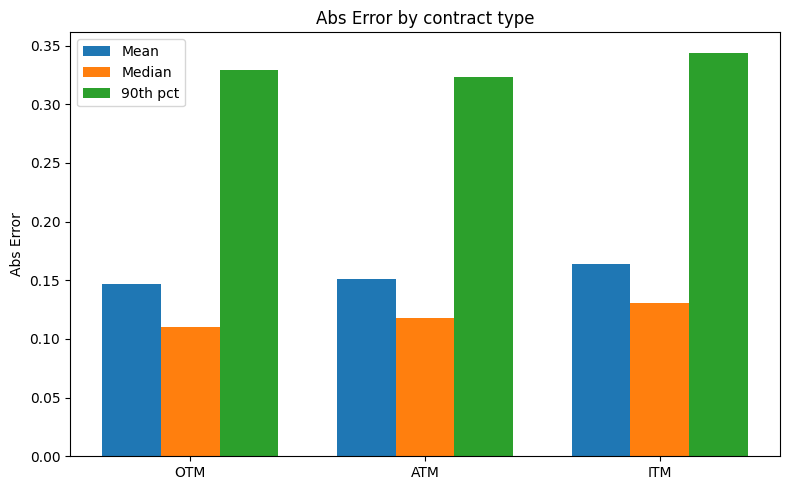

/tmp/ipykernel_1412/1897942831.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


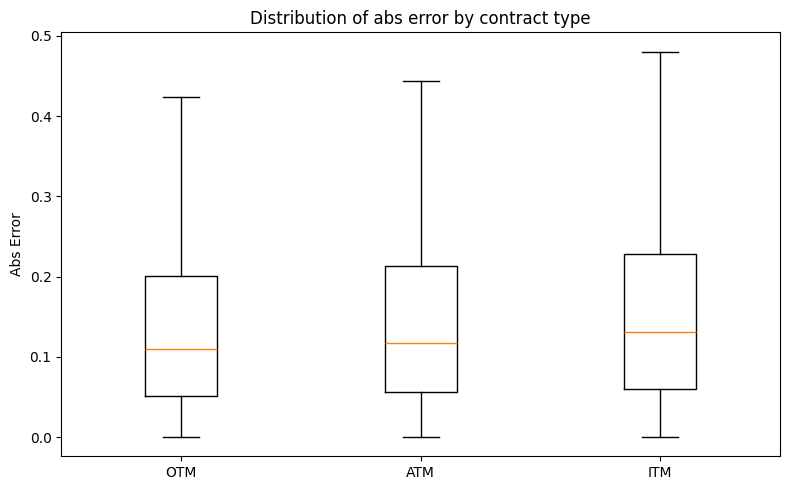

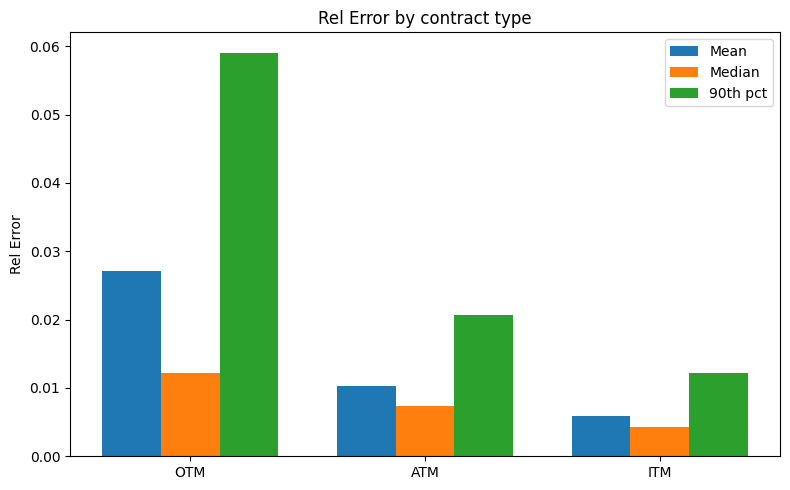

/tmp/ipykernel_1412/1897942831.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


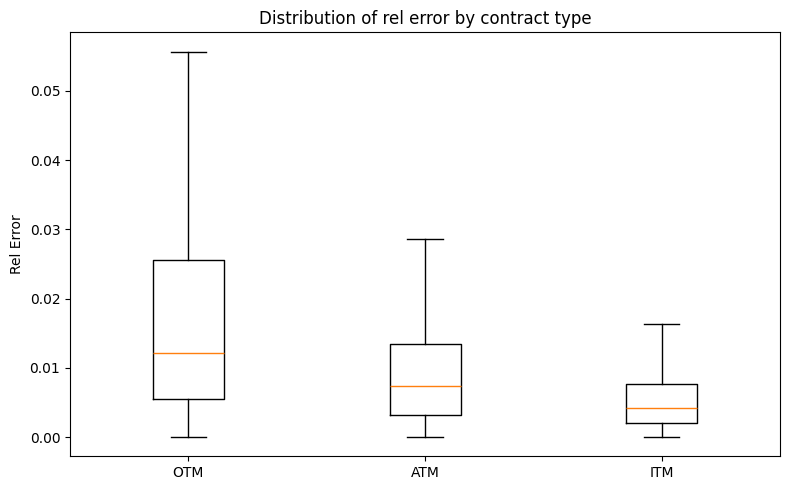

In [ ]:
plot_error_by_contract_type(df_test, error_col="abs_error")
boxplot_error_by_contract_type(df_test, error_col="abs_error")

plot_error_by_contract_type(df_test_rel, error_col="rel_error")
boxplot_error_by_contract_type(df_test_rel, error_col="rel_error")

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


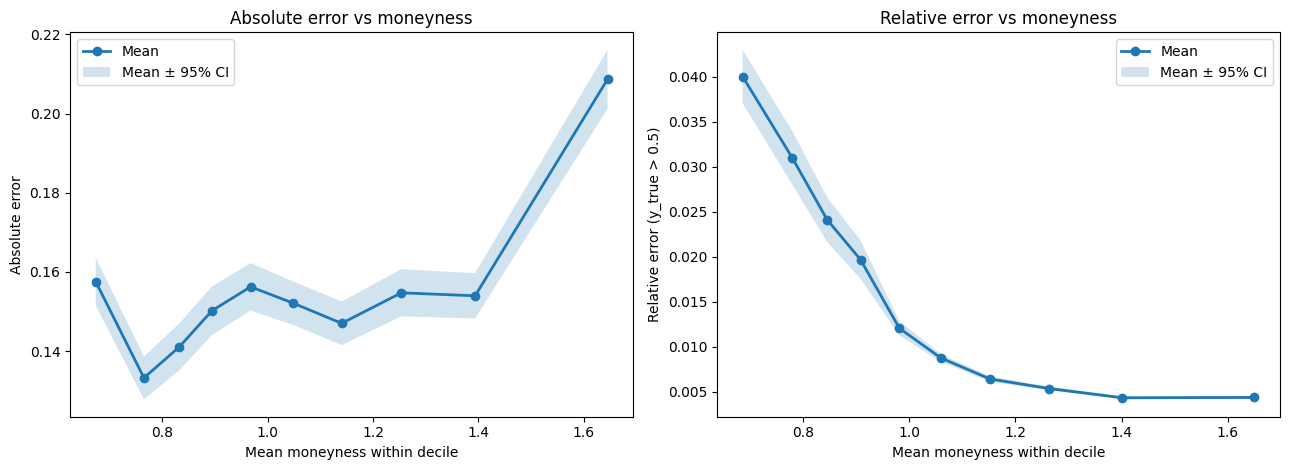

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


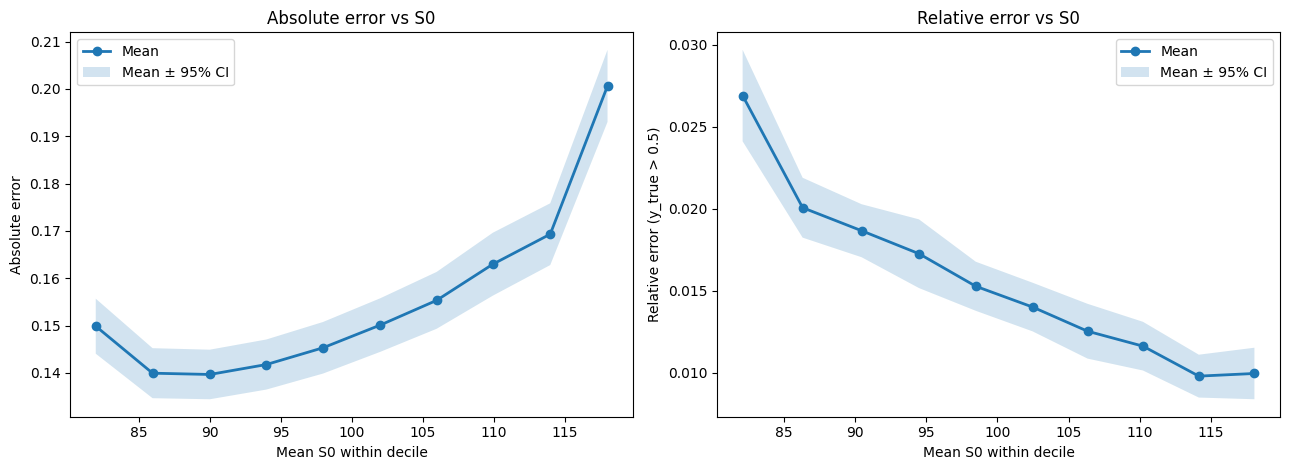

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


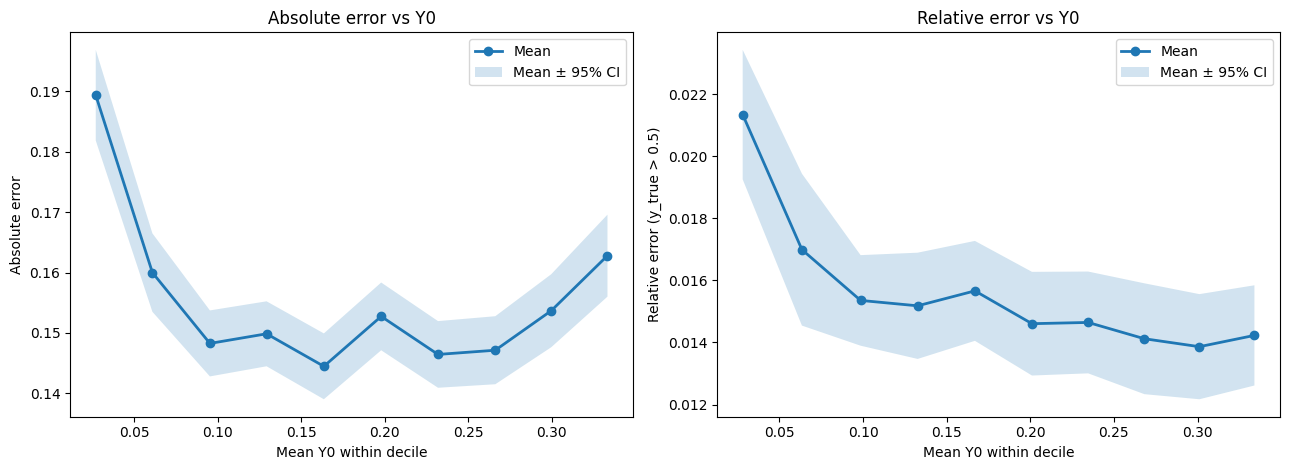

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


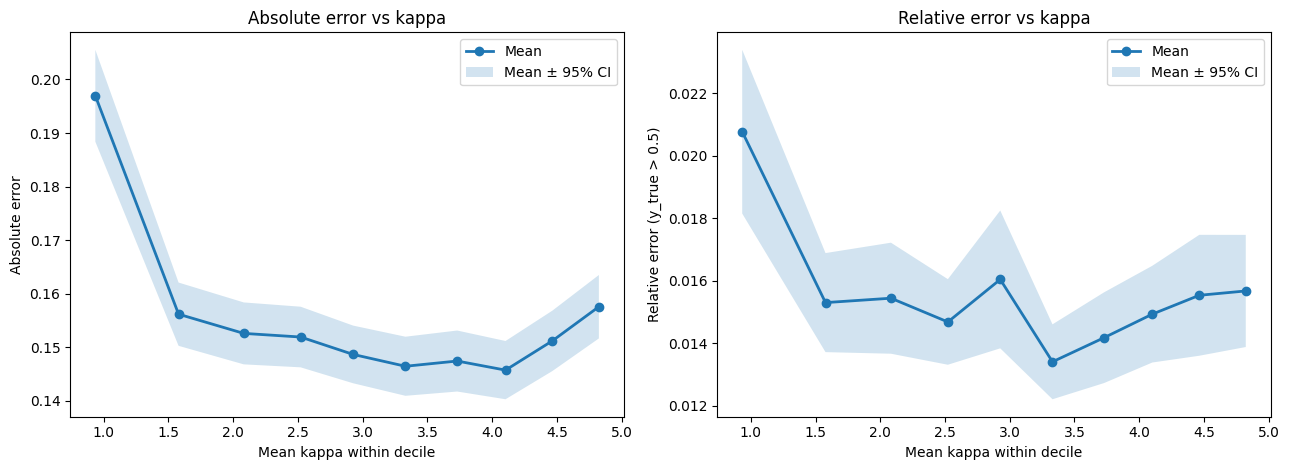

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


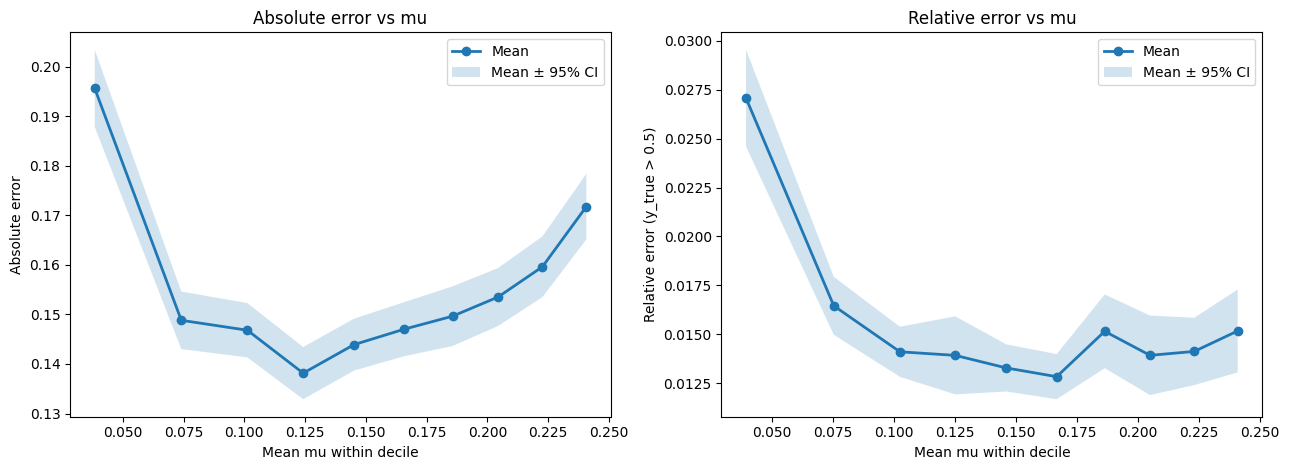

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


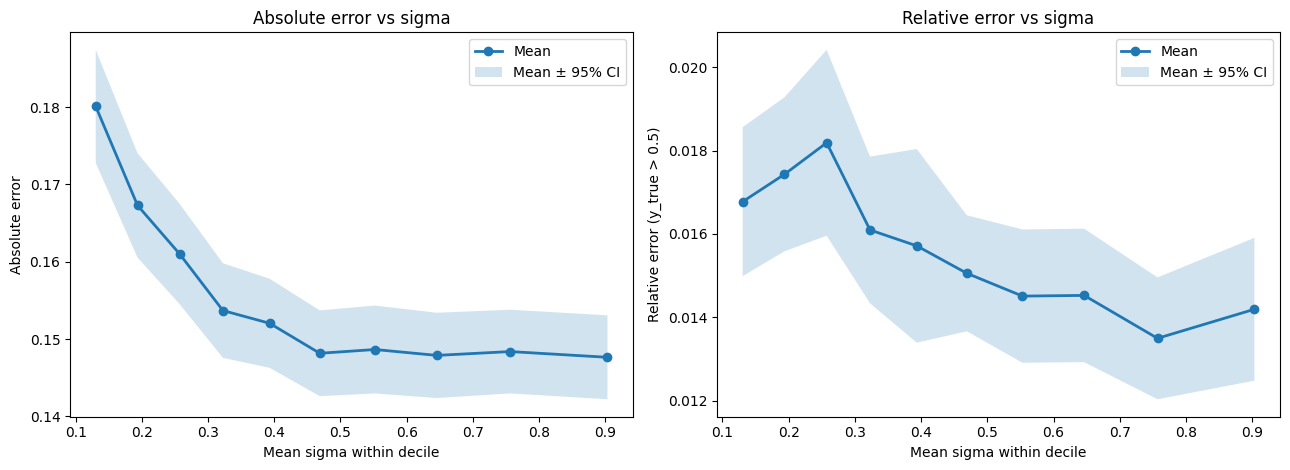

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


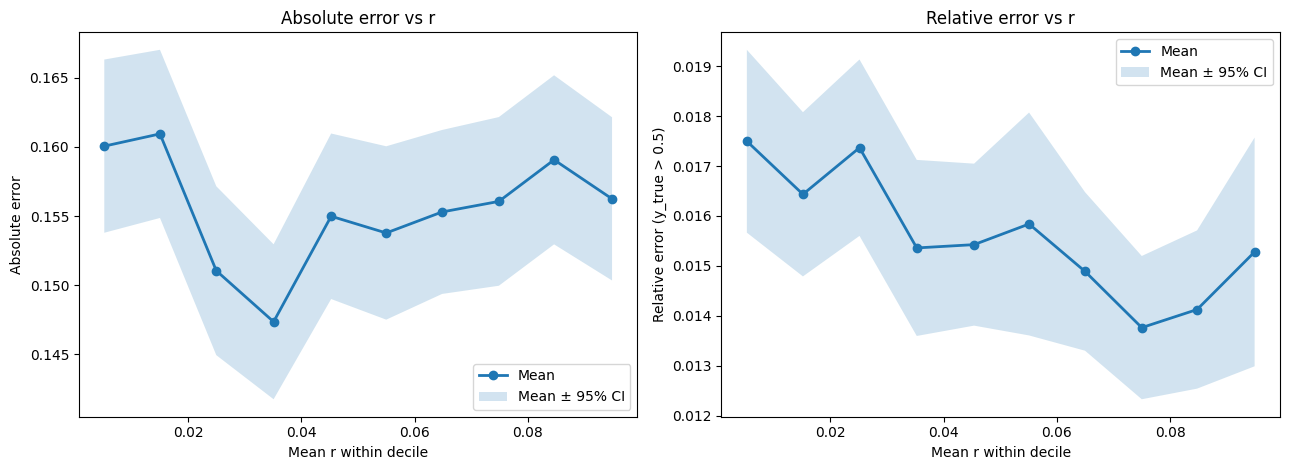

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


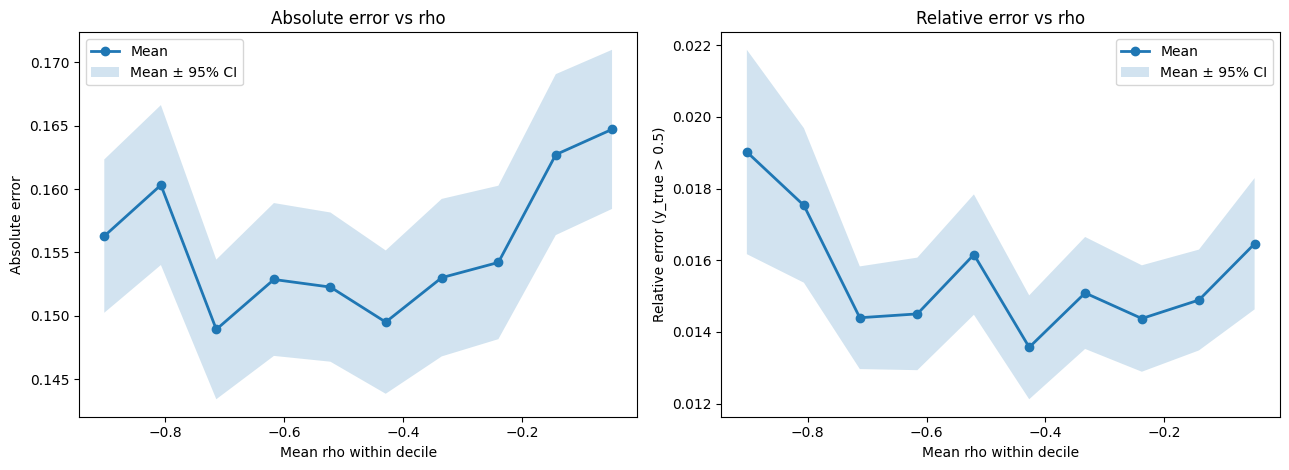

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


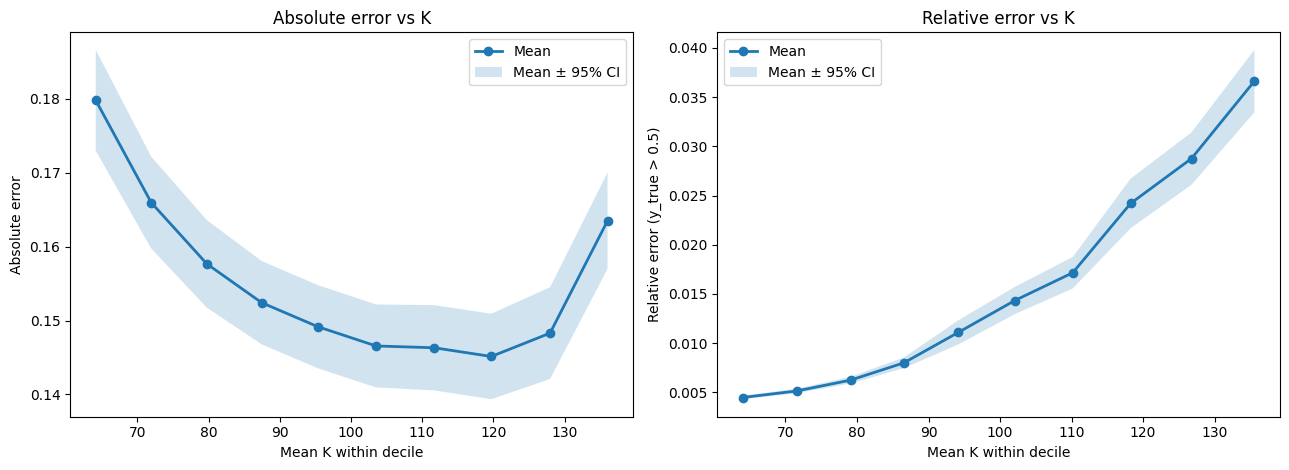

/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)
/tmp/ipykernel_1412/1897942831.py:245: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_bin)


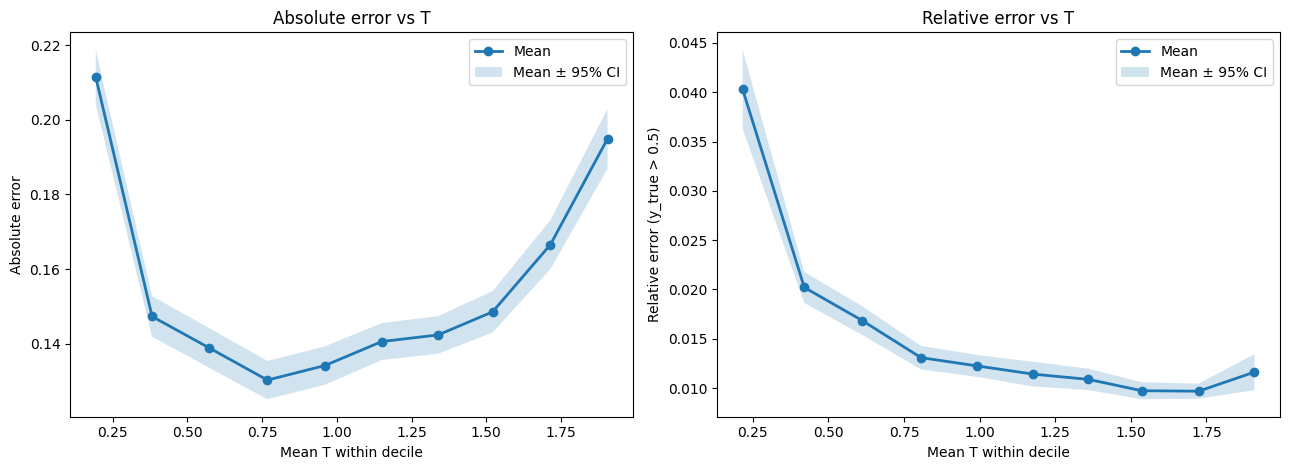

In [ ]:
plot_all_features_abs_rel_side_by_side(df_test, n_bins=10, ci_level=0.95, min_price_rel=MIN_PRICE_REL)

# Comparison of accuracy with larger model (more neuron and more layers)

In [23]:
class HestonMLPLarge(nn.Module):
    def __init__(self, input_dim=9, dropout=0.05):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(dropout)

        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.drop5 = nn.Dropout(dropout)

        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)
        self.drop6 = nn.Dropout(dropout)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.drop4(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = F.relu(x)
        x = self.drop5(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = F.relu(x)
        x = self.drop6(x)

        x = self.out(x)
        return x

model_large = HestonMLPLarge(input_dim=9, dropout=0.05).to(device)
print(model_large)

HestonMLPLarge(
  (fc1): Linear(in_features=9, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.05, inplace=False)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.05, inplace=False)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop4): Dropout(p=0.05, inplace=False)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop5): Dropout(p=0.05, inplace=False)
  (fc6): Linear(

In [24]:
model, history = train_model(
    model_large,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    grad_clip=None,
    device=device
)



Epoch 001 | train_loss=9.225237 | train_mae=18.697485 | val_mae=17.242517 | val_rmse=21.890251 | val_rel_total=4.168354 | val_rel_atm=0.791333 | lr=1.00e-03


Epoch 002 | train_loss=7.382673 | train_mae=15.008391 | val_mae=12.409106 | val_rmse=16.969467 | val_rel_total=1.287799 | val_rel_atm=0.546916 | lr=1.00e-03


Epoch 003 | train_loss=4.480318 | train_mae=9.201450 | val_mae=3.299676 | val_rmse=4.844943 | val_rel_total=3.456580 | val_rel_atm=0.237948 | lr=1.00e-03


Epoch 004 | train_loss=1.011220 | train_mae=2.253384 | val_mae=0.831226 | val_rmse=1.176319 | val_rel_total=4.106226 | val_rel_atm=0.068950 | lr=1.00e-03


Epoch 005 | train_loss=0.453179 | train_mae=1.127020 | val_mae=0.548358 | val_rmse=0.741229 | val_rel_total=4.151180 | val_rel_atm=0.056045 | lr=1.00e-03


...

Epoch 069 | train_loss=0.300812 | train_mae=0.810449 | val_mae=0.210768 | val_rmse=0.272659 | val_rel_total=5.078496 | val_rel_atm=0.017929 | lr=1.00e-05


Epoch 070 | train_loss=0.301410 | train_mae=0.812459 | val_mae=0.182967 | val_rmse=0.234744 | val_rel_total=5.078057 | val_rel_atm=0.016762 | lr=1.00e-05


Epoch 071 | train_loss=0.303778 | train_mae=0.816791 | val_mae=0.174287 | val_rmse=0.238164 | val_rel_total=5.077545 | val_rel_atm=0.014941 | lr=1.00e-05


Epoch 072 | train_loss=0.305139 | train_mae=0.820212 | val_mae=0.150928 | val_rmse=0.201521 | val_rel_total=5.077550 | val_rel_atm=0.014404 | lr=1.00e-05


Epoch 073 | train_loss=0.312887 | train_mae=0.837089 | val_mae=0.159238 | val_rmse=0.214546 | val_rel_total=5.078960 | val_rel_atm=0.014856 | lr=1.00e-05
Early stopping triggered after epoch 73.


In [25]:
train_metrics, train_preds, train_targets = evaluate_model(model, train_loader, device=device)
val_metrics, val_preds, val_targets = evaluate_model(model, val_loader, device=device)
test_metrics, test_preds, test_targets = evaluate_model(model, test_loader, device=device)

print("\nFinal metrics")
print("TRAIN:", train_metrics)
print("VAL  :", val_metrics)
print("TEST :", test_metrics)


Final metrics
TRAIN: {'mae': 0.14385290443897247, 'rmse': 0.1938917487859726, 'rel_err_total': 5.739223480224609, 'rel_err_atm': 0.014625193551182747, 'error_mean': 0.016137883067131042, 'error_std': 0.19321900606155396, 'abs_p50': 0.11088132858276367, 'abs_p90': 0.3017576336860657, 'abs_p95': 0.38273608684539795, 'abs_p99': 0.594184935092926}
VAL  : {'mae': 0.14804843068122864, 'rmse': 0.19787171483039856, 'rel_err_total': 5.067091464996338, 'rel_err_atm': 0.014166069217026234, 'error_mean': 0.01425202377140522, 'error_std': 0.19735777378082275, 'abs_p50': 0.113983154296875, 'abs_p90': 0.31416797637939453, 'abs_p95': 0.39387911558151245, 'abs_p99': 0.5807279348373413}
TEST : {'mae': 0.13385289907455444, 'rmse': 0.18245527148246765, 'rel_err_total': 5.721246719360352, 'rel_err_atm': 0.01393065880984068, 'error_mean': 0.01820898987352848, 'error_std': 0.18154436349868774, 'abs_p50': 0.10326051712036133, 'abs_p90': 0.2785663902759552, 'abs_p95': 0.35249412059783936, 'abs_p99': 0.5577541

In [26]:
class HestonMLPSmall(nn.Module):
    def __init__(self, input_dim=9, dropout=0.05):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop3 = nn.Dropout(dropout)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.drop3(x)

        x = self.out(x)
        return x

model_small = HestonMLPSmall(input_dim=9, dropout=0.05).to(device)
print(model_small)

HestonMLPSmall(
  (fc1): Linear(in_features=9, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.05, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.05, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
)


In [27]:
model, history = train_model(
    model_small,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    grad_clip=None,
    device=device
)

Epoch 001 | train_loss=9.465098 | train_mae=19.177891 | val_mae=17.913378 | val_rmse=22.555550 | val_rel_total=4.102428 | val_rel_atm=0.828019 | lr=1.00e-03


Epoch 002 | train_loss=7.612795 | train_mae=15.470975 | val_mae=12.445839 | val_rmse=16.657635 | val_rel_total=7.678905 | val_rel_atm=0.553271 | lr=1.00e-03


Epoch 003 | train_loss=4.477828 | train_mae=9.199632 | val_mae=4.502872 | val_rmse=6.688246 | val_rel_total=6.185409 | val_rel_atm=0.263482 | lr=1.00e-03


Epoch 004 | train_loss=1.061365 | train_mae=2.355057 | val_mae=0.891225 | val_rmse=1.104005 | val_rel_total=7.004184 | val_rel_atm=0.090541 | lr=1.00e-03


Epoch 005 | train_loss=0.422249 | train_mae=1.064978 | val_mae=0.376567 | val_rmse=0.499108 | val_rel_total=7.055716 | val_rel_atm=0.042343 | lr=1.00e-03


...

Epoch 084 | train_loss=0.302006 | train_mae=0.814762 | val_mae=0.204948 | val_rmse=0.276661 | val_rel_total=7.799594 | val_rel_atm=0.020625 | lr=1.00e-05


Epoch 085 | train_loss=0.306579 | train_mae=0.824296 | val_mae=0.247777 | val_rmse=0.326005 | val_rel_total=7.801333 | val_rel_atm=0.022570 | lr=1.00e-05


Epoch 086 | train_loss=0.289179 | train_mae=0.788249 | val_mae=0.183646 | val_rmse=0.243679 | val_rel_total=7.799724 | val_rel_atm=0.020190 | lr=1.00e-05


Epoch 087 | train_loss=0.295691 | train_mae=0.802055 | val_mae=0.186835 | val_rmse=0.247783 | val_rel_total=7.800015 | val_rel_atm=0.020237 | lr=1.00e-05


Epoch 088 | train_loss=0.289927 | train_mae=0.789957 | val_mae=0.186378 | val_rmse=0.245561 | val_rel_total=7.800605 | val_rel_atm=0.020541 | lr=1.00e-05
Early stopping triggered after epoch 88.


In [28]:
train_metrics, train_preds, train_targets = evaluate_model(model, train_loader, device=device)
val_metrics, val_preds, val_targets = evaluate_model(model, val_loader, device=device)
test_metrics, test_preds, test_targets = evaluate_model(model, test_loader, device=device)

print("\nFinal metrics")
print("TRAIN:", train_metrics)
print("VAL  :", val_metrics)
print("TEST :", test_metrics)


Final metrics
TRAIN: {'mae': 0.17862389981746674, 'rmse': 0.2360556423664093, 'rel_err_total': 8.830083847045898, 'rel_err_atm': 0.020428767427802086, 'error_mean': 0.02632727287709713, 'error_std': 0.23458290100097656, 'abs_p50': 0.14134883880615234, 'abs_p90': 0.37721961736679077, 'abs_p95': 0.4575513005256653, 'abs_p99': 0.7001422643661499}
VAL  : {'mae': 0.18232734501361847, 'rmse': 0.23966947197914124, 'rel_err_total': 7.795821666717529, 'rel_err_atm': 0.02014988474547863, 'error_mean': 0.018928389996290207, 'error_std': 0.23892085254192352, 'abs_p50': 0.14477920532226562, 'abs_p90': 0.3831344544887543, 'abs_p95': 0.4657233953475952, 'abs_p99': 0.6872080564498901}
TEST : {'mae': 0.17083854973316193, 'rmse': 0.22754792869091034, 'rel_err_total': 8.800926208496094, 'rel_err_atm': 0.019766829907894135, 'error_mean': 0.02846182882785797, 'error_std': 0.22576089203357697, 'abs_p50': 0.1341567039489746, 'abs_p90': 0.3600020110607147, 'abs_p95': 0.4353359341621399, 'abs_p99': 0.66269326

In [ ]:
class HestonMLPVeryLarge(nn.Module):
    def __init__(self, input_dim=9, dropout=0.05):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(dropout)

        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.drop5 = nn.Dropout(dropout)

        self.fc6 = nn.Linear(128, 128)
        self.bn6 = nn.BatchNorm1d(128)
        self.drop6 = nn.Dropout(dropout)

        self.fc7 = nn.Linear(128, 64)
        self.bn7 = nn.BatchNorm1d(64)
        self.drop7 = nn.Dropout(dropout)

        self.fc8 = nn.Linear(64, 64)
        self.bn8 = nn.BatchNorm1d(64)
        self.drop8 = nn.Dropout(dropout)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.drop4(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = F.relu(x)
        x = self.drop5(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = F.relu(x)
        x = self.drop6(x)

        x = self.fc7(x)
        x = self.bn7(x)
        x = F.relu(x)
        x = self.drop7(x)

        x = self.fc8(x)
        x = self.bn8(x)
        x = F.relu(x)
        x = self.drop8(x)

        x = self.out(x)
        return x

model_verylarge = HestonMLPVeryLarge(input_dim=9, dropout=0.05).to(device)
print(model_verylarge)


model_verylarge, history = train_model(
    model_verylarge,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    patience=15,
    grad_clip=None,
    device=device
)


train_metrics, train_preds, train_targets = evaluate_model(model_verylarge, train_loader, device=device)
val_metrics, val_preds, val_targets = evaluate_model(model_verylarge, val_loader, device=device)
test_metrics, test_preds, test_targets = evaluate_model(model_verylarge, test_loader, device=device)

print("\nFinal metrics")
print("TRAIN:", train_metrics)
print("VAL  :", val_metrics)
print("TEST :", test_metrics)